# Customer Segmentation Analysis using RFM and K-Means Clustering

## Objective
The objective of this analysis is to segment customers based on purchasing behavior using RFM metrics and K-Means clustering.

This analysis helps:
- Identify high-value customers
- Detect at-risk customers
- Improve customer retention
- Optimize marketing strategies

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load Dataset

In [3]:
# Load processed dataset

df = pd.read_csv("Dataset/Cleaned_data/master_df.csv")

# Display first rows

df.head()

,CustomerID,Transaction_ID,Transaction_Date,Month,Date,Week,Product_SKU,Product_Description,Product_Category,ABC,...,Total_Marketing_Spend,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Heuristic_Segment,KMeans_Label
0,17850,16679,2019-01-01,Jan,2019-01-01,2018-12-31/2019-01-06,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,A,...,6924.5,340,177,40540.13564,1,4,4,9,Premium,3
1,17850,16680,2019-01-01,Jan,2019-01-01,2018-12-31/2019-01-06,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,A,...,6924.5,340,177,40540.13564,1,4,4,9,Premium,3
2,17850,16681,2019-01-01,Jan,2019-01-01,2018-12-31/2019-01-06,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,B,...,6924.5,340,177,40540.13564,1,4,4,9,Premium,3
3,17850,16682,2019-01-01,Jan,2019-01-01,2018-12-31/2019-01-06,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,A,...,6924.5,340,177,40540.13564,1,4,4,9,Premium,3
4,17850,16682,2019-01-01,Jan,2019-01-01,2018-12-31/2019-01-06,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,B,...,6924.5,340,177,40540.13564,1,4,4,9,Premium,3


In [4]:
# Convert Transaction_Date to datetime

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"]
)

# Check datatype

print(df["Transaction_Date"].dtype)

datetime64[us]


# 2. RFM Analysis

RFM analysis measures customer value using three metrics:

- Recency: Number of days since the last purchase
- Frequency: Number of purchases
- Monetary: Total spending amount

In [5]:
# Create RFM table

today = df["Transaction_Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("Transaction_Date",
              lambda x: (today - x.max()).days),

    Frequency=("Transaction_ID", "nunique"),

    Monetary=("Invoice", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,108,1,174.98174
1,12347,60,31,15686.84396
2,12348,74,8,1689.55594
3,12350,18,11,1467.43528
4,12356,108,13,2007.42900


# 3. RFM Scoring

Each customer receives scores from 1 to 4:
- Lower Recency = higher score
- Higher Frequency = higher score
- Higher Monetary = higher score

In [6]:
# Calculate RFM scores

rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=4,
    labels=[4,3,2,1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,108,1,174.98174,3,1,1,5
1,12347,60,31,15686.84396,3,4,4,11
2,12348,74,8,1689.55594,3,2,2,7
3,12350,18,11,1467.43528,4,2,2,8
4,12356,108,13,2007.42900,3,3,2,8


# 4. Heuristic Customer Segmentation

Customers are grouped into four categories based on their RFM scores:
- Standard
- Silver
- Premium
- Gold

 

In [7]:
# Define heuristic segmentation function

def heuristic_segment(score):

    if score <= 5:
        return "Standard"

    elif score <= 8:
        return "Silver"

    elif score <= 10:
        return "Premium"

    else:
        return "Gold"

# Apply segmentation

rfm["Heuristic_Segment"] = (
    rfm["RFM_Score"]
    .apply(heuristic_segment)
)

# Display segment distribution

rfm["Heuristic_Segment"].value_counts()

Heuristic_Segment
Silver      494
Standard    407
Premium     315
Gold        252
Name: count, dtype: int64

# 5. Data Standardization

In [33]:
# Select RFM features

kmeans_features = rfm[
    ["Recency", "Frequency", "Monetary"]
]

# Standardize features

scaler = StandardScaler()

kmeans_scaled = scaler.fit_transform(
    kmeans_features
)

# 6. Determining Optimal Number of Clusters

The Elbow Method is used to identify the optimal number of customer clusters.

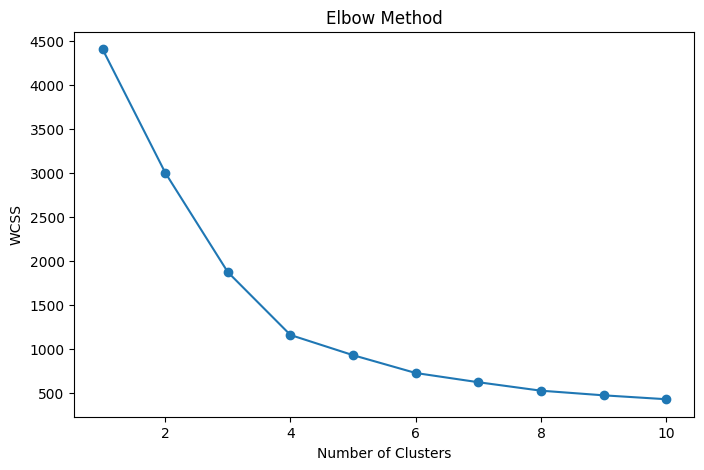

In [34]:
# Elbow Method

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(kmeans_scaled)

    wcss.append(kmeans.inertia_)

# Plot elbow chart

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

The Elbow chart shows a clear break at cluster number 4, confirming that 4 is the optimal number of customer segments.

# 7. K-Means Clustering

In [35]:
# Apply KMeans clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["KMeans_Label"] = (
    kmeans.fit_predict(kmeans_scaled)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Heuristic_Segment,KMeans_Label
0,12346,108,1,174.98174,3,1,1,5,Standard,2
1,12347,60,31,15686.84396,3,4,4,11,Gold,0
2,12348,74,8,1689.55594,3,2,2,7,Silver,2
3,12350,18,11,1467.43528,4,2,2,8,Silver,2
4,12356,108,13,2007.42900,3,3,2,8,Silver,2


# 8. Cluster Profile Analysis

In [36]:
# Cluster summary

cluster_profile = rfm.groupby(
    "KMeans_Label"
)[["Recency","Frequency","Monetary"]].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
KMeans_Label,,,
0,80.26,55.69,11932.70
1,255.17,10.29,1969.64
2,79.25,12.79,2433.38
3,81.83,270.67,65739.45


# 9. Cluster Interpretation

Cluster characteristics:

- Cluster 3: VIP Customers
- Cluster 0: Loyal Customers
- Cluster 2: Regular Customers
- Cluster 1: At Risk Customers

In [37]:
# Assign cluster names

cluster_names = {

    0: "Loyal Customers",

    1: "At Risk Customers",

    2: "Regular Customers",

    3: "VIP Customers"
}

rfm["Cluster_Name"] = (
    rfm["KMeans_Label"]
    .map(cluster_names)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Heuristic_Segment,KMeans_Label,Cluster_Name
0,12346,108,1,174.98174,3,1,1,5,Standard,2,Regular Customers
1,12347,60,31,15686.84396,3,4,4,11,Gold,0,Loyal Customers
2,12348,74,8,1689.55594,3,2,2,7,Silver,2,Regular Customers
3,12350,18,11,1467.43528,4,2,2,8,Silver,2,Regular Customers
4,12356,108,13,2007.42900,3,3,2,8,Silver,2,Regular Customers


# 10. Customer Distribution by Cluster

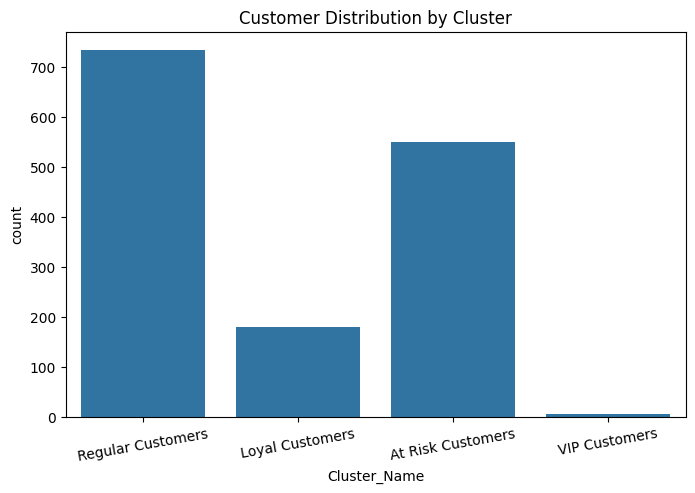

In [38]:
# Visualize customer distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="Cluster_Name"
)

plt.title(
    "Customer Distribution by Cluster"
)

plt.xticks(rotation=10)

plt.show()

The Loyal and Regular groups make up the majority, while the VIP group is small but high-value => therefore, maintain service quality for the Loyal group and build an upsell program for the Regular group.

# 11. Frequency vs Monetary Visualization

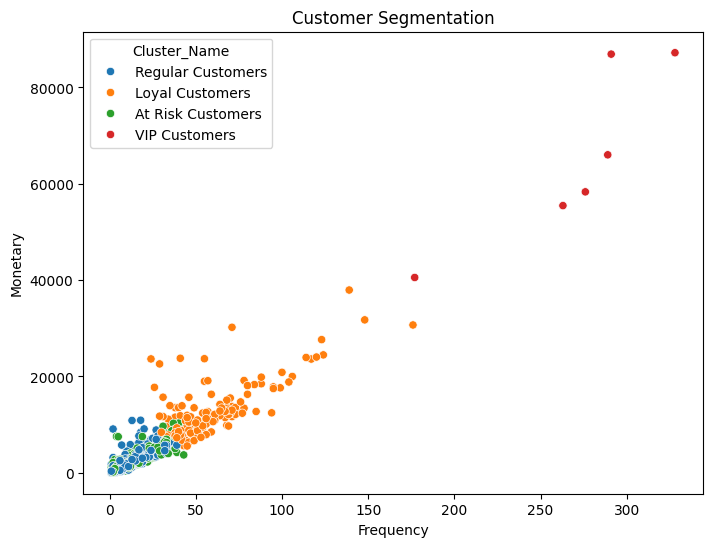

In [39]:
# Scatter plot for customer segmentation

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster_Name"
)

plt.title("Customer Segmentation")

plt.show()

The scatter plot shows that the VIP group has both high purchase frequency and high spending power, making them the core customer group for revenue growth. The At Risk group is in the low Frequency and Monetary range and requires policies to encourage repeat purchases.

# 12. Heatmap of Cluster Profiles

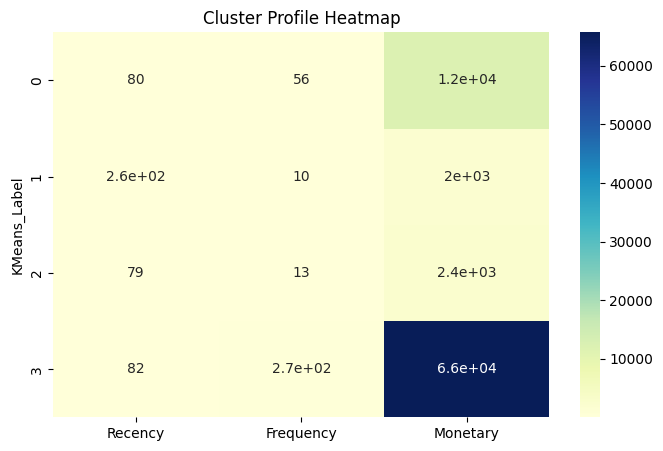

In [40]:
# Heatmap visualization

plt.figure(figsize=(8,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Cluster Profile Heatmap"
)

plt.show()

The heatmap clearly shows the differences between customer groups. The VIP group stands out with the highest metrics, the At Risk group has the highest Recency => therefore, marketing campaigns should be personalized for each of these groups.